In [1]:
import sys
import os

# Add project root to Python path (works in notebooks)
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

In [2]:
from dotenv import load_dotenv
load_dotenv()


True

In [3]:
from RAG.retriever import Retrieval
from RAG.generator import Generator
from Evaluation.evaluation import Eval_Pipeline
import torch
import gc

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from langsmith import Client
client = Client()


In [5]:
print(client.list_projects())

<generator object Client.list_projects at 0x00000270796870D0>


GPU memory cleared
Allocated: 0.00 MiB
Cached: 0.00 MiB

📦 Loading model meta-llama/Llama-3.2-1B-Instruct on cuda...


`torch_dtype` is deprecated! Use `dtype` instead!
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\accelerate\utils\modeling.py:821: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  _ = torch.tensor([0], device=i)


✅ Model loaded successfully.
Dataset({
    features: ['question', 'contexts', 'reference', 'answer'],
    num_rows: 1
})


c:\Users\user\Documents\RAG_Fact_Checking\Evaluation\metric_runner.py:24: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  return HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
Loading checkpoint shards: 100%|██████████| 2/2 [00:37<00:00, 18.70s/it]
Device set to use cpu
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
c:\Users\user\Documents\RAG_Fact_Checking\Evaluation\metric_runner.py:38: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class 

✅ Results saved to evaluation/results/results.csv
📊 Preview of results:
                         user_input  \
0  What is RAG in machine learning?   

                                  retrieved_contexts  \
0  [chen, xuejing liu, jialin wang, wenbin ge, si...   

                      response  \
0  RAG (Reducing Attention Gap   

                                           reference  faithfulness  \
0  RAG (Retrieval-Augmented Generation) is a fram...           NaN   

   context_precision  context_recall  answer_relevancy  mean_score  
0                NaN             NaN               NaN         NaN  


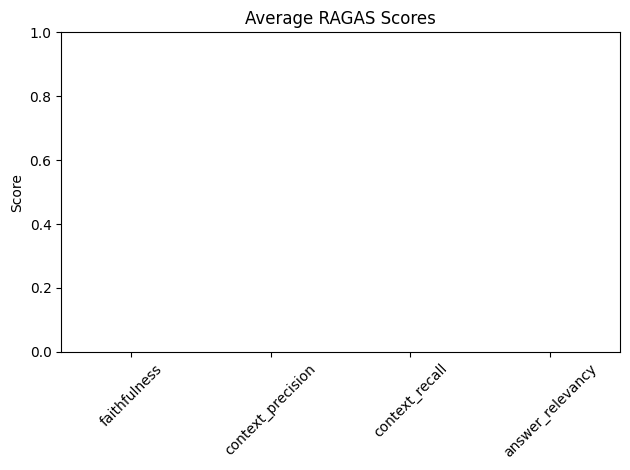

: 

In [ ]:
gc.collect()
torch.cuda.empty_cache()

print("GPU memory cleared")
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MiB")
print(f"Cached: {torch.cuda.memory_reserved() / 1024**2:.2f} MiB")


retriever = Retrieval()
generator = Generator()

test_data = [
{"query": "What is RAG in machine learning?", "expected": "RAG (Retrieval-Augmented Generation) is a framework that combines retrieval of external documents with generation by a language model."}]
#{"query": "Explain transformer models.", "expected": "Transformer models are neural networks that use self-attention mechanisms to process sequential data efficiently."},
#{"query": "What are embeddings in NLP?", "expected": "Embeddings are vector representations of words, sentences, or documents used to capture semantic meaning."},
#]


pipeline = Eval_Pipeline(retriever, generator)
df = pipeline.run(test_data)

In [9]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
model_id = "microsoft/phi-3-mini-4k-instruct"   # small, cheap; swap for a better model if you like
tok = AutoTokenizer.from_pretrained(model_id)
mdl = AutoModelForCausalLM.from_pretrained(model_id)

Loading checkpoint shards:   0%|          | 0/2 [00:16<?, ?it/s]


KeyboardInterrupt: 

In [5]:
from Evaluation.dataset_builder import DatasetBuilder
retriever = Retrieval()
generator = Generator()
data=DatasetBuilder(retriever,generator)
test_data = [
{"query": "What is RAG in machine learning?", "expected": "RAG (Retrieval-Augmented Generation) is a framework that combines retrieval of external documents with generation by a language model."}]

df=data.build(test_data)





📦 Loading model meta-llama/Llama-3.2-1B-Instruct on cuda...


`torch_dtype` is deprecated! Use `dtype` instead!
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\accelerate\utils\modeling.py:821: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  _ = torch.tensor([0], device=i)


✅ Model loaded successfully.


In [ ]:
from Evaluation.metric_runner import MetricRunner

metric=MetricRunner()
metrics=metric.run(df)
print(metrics)

Evaluating:  50%|█████     | 6/12 [02:38<01:27, 14.53s/it]Exception raised in Job[2]: RateLimitError(Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}})
Exception raised in Job[3]: RateLimitError(Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}})
Evaluating:  83%|████████▎ | 10/12 [02:56<00:17,  8.61s/it]Exception raised in Job[0]: TimeoutError()
Exception raised in Job[6]: TimeoutError()
Evaluating: 100%|██████████| 12/12 [03:00<00:00, 15.00s/it]


                         user_input  \
0  What is RAG in machine learning?   
1       Explain transformer models.   
2       What are embeddings in NLP?   

                                  retrieved_contexts  \
0  [chen, xuejing liu, jialin wang, wenbin ge, si...   
1  [sr ) * * was proposed by benzi et al. ( 1981 ...   
2  [provides equal spatial modeling capacity acro...   

                                            response  \
0  RAG is a technique used in machine learning to...   
1  A transformer model is a type of neural networ...   
2  In NLP (Natural Language Processing), embeddin...   

                                           reference  faithfulness  \
0  RAG (Retrieval-Augmented Generation) is a fram...           NaN   
1  Transformer models are neural networks that us...           NaN   
2  Embeddings are vector representations of words...           NaN   

   answer_relevancy  context_precision  context_recall  mean_score  
0               NaN                NaN     

In [ ]:
print(df)

Dataset({
    features: ['user_input', 'retrieved_contexts', 'reference', 'response'],
    num_rows: 3
})


In [ ]:
from RAG.chunking import SciBERTChunker
from config import CHUNKED_JSON
print(type(SciBERTChunker.load_articles(CHUNKED_JSON)[0]))

<class 'dict'>


In [ ]:
from RAG.retriever import Retrieval
retriever=Retrieval()

print(retriever.retrieve(query="How Quantization work"))

[Document(metadata={}, page_content='sr ) * * was proposed by benzi et al. ( 1981 ) and first applied in climate dynamics ( benzi et al., 1982 ) and later in signal processing ( wellens et al., 2003 ; kosko & mitaim, 2001 ; chen et al., 2007 ) and acoustics ( shu - yao et al., 2016 ; wang et al., 2014 ). recently, stochas 3 preprint version. under review. tic resonance transformer ( srt ) lao et al. ( 2024 ) uses sr to “ super - resolve ” vision transformer ( vit ) embeddings. in this work, we instead use sr to mitigate adversarial perturbations. since sr has been developed specifically to address _ quantization artifacts _, it has never before been used to mitigate classes of perturbations beyond aliasing. our novel use of the technique leverages the fact that group transformations and spatial quantization preserve the statistics of natural images, which are heavy - tailed, but do not preserve the statistics of adversarial perturbations. 3 m ethod * * notation. * * a digital image _ x

In [ ]:
from RAG.rag import RAG
import torch
import gc

gc.collect()
torch.cuda.empty_cache()


print("GPU memory cleared")
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MiB")
print(f"Cached: {torch.cuda.memory_reserved() / 1024**2:.2f} MiB")
rag_instance = RAG()                # create an instance
answer = rag_instance.ask(query="How do RAG work")  # ✅ call the method
print(answer)

GPU memory cleared
Allocated: 2366.25 MiB
Cached: 2380.00 MiB
📦 Loading model meta-llama/Llama-3.2-1B-Instruct on cuda...


Some parameters are on the meta device because they were offloaded to the cpu.


✅ Model loaded successfully.
RAG stands for Reward Alignment. It is a machine learning approach that ensures the model is not over-optimizing, i.e., it is not trying to maximize the reward as much as possible. In other words, RAG is a way to keep the model from being too greedy and getting stuck in a local optimum.

To understand RAG, let's consider a simple example. Imagine a model is trying to predict the outcome of a game. The model is given a set of rules and probabilities, and it needs to make a decision based on those rules. The reward is the score the model gets for making the right decision.

The problem with RAG is that the model is trying to maximize the reward, but it's doing so in a way that's not very effective. It's like a greedy algorithm that's always trying to maximize the reward, even if it means making a wrong decision. This can lead to suboptimal outcomes, such as the model getting stuck in a local optimum or making incorrect decisions.

RAG works by adding a penalt

In [6]:
from typing import List, Dict, Any
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall
)
from ragas import evaluate
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

class ScientificRAGEvaluator:
    """
    Classe d'évaluation pour un pipeline RAG de QA scientifique utilisant les métriques de RAGAS :
    - Faithfulness : cohérence factuelle entre la réponse et le contexte.
    - Answer Relevancy : pertinence de la réponse par rapport à la question.
    - Context Precision : précision des contextes récupérés.
    - Context Recall : rappel des informations pertinentes par rapport au ground truth.
    """

    def __init__(self,device: str = None,token: str=None):
        """
        Initialise l'évaluateur avec un modèle de langage pour RAGAS.

        Paramètres :
        llm : objet compatible LangChain ou Ragas (peut être un model wrapper type OpenAI, HuggingFaceHub, etc.)
        """
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.token=token or os.getenv("HF_TOKEN")
        self.llm = AutoModelForCausalLM.from_pretrained(
            "meta-llama/Llama-3.2-1B-Instruct",
            torch_dtype=torch.float16 if self.device == "cuda" else torch.float32,
            device_map="auto" if self.device == "cuda" else None,
            token=self.token
        )



    def evaluate_pipeline(self, dataset: Dataset) -> Dict[str, Any]:
        """
        Calcule les scores globaux de performance du pipeline RAG selon les métriques RAGAS.

        Retourne un dictionnaire contenant les moyennes pour chaque métrique.
        """
        results =  evaluate(
            dataset=dataset,
            metrics=[
                faithfulness,
                answer_relevancy,
                context_precision,
                context_recall
            ],
            llm=self.llm
        )

        return {
            "faithfulness": results["faithfulness"].mean(),
            "answer_relevancy": results["answer_relevancy"].mean(),
            "context_precision": results["context_precision"].mean(),
            "context_recall": results["context_recall"].mean(),
        }

In [ ]:
evaluate=ScientificRAGEvaluator()


In [10]:
evaluation=evaluate.evaluate_pipeline(df)

TypeError: 'ScientificRAGEvaluator' object is not callable

In [3]:
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_huggingface import HuggingFacePipeline
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
import torch
import gc
gc.collect()
torch.cuda.empty_cache()

print("GPU memory cleared")
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MiB")
print(f"Cached: {torch.cuda.memory_reserved() / 1024**2:.2f} MiB")


model_id = "microsoft/phi-3-mini-4k-instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)


GPU memory cleared
Allocated: 11080.56 MiB
Cached: 11082.00 MiB


In [4]:
gc.collect()
torch.cuda.empty_cache()
model = AutoModelForCausalLM.from_pretrained(model_id)


Loading checkpoint shards: 100%|██████████| 2/2 [00:40<00:00, 20.43s/it]


In [5]:
gc.collect()
torch.cuda.empty_cache()
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=10,
)


Device set to use cuda:0


OutOfMemoryError: CUDA out of memory. Tried to allocate 376.00 MiB. GPU 0 has a total capacity of 4.00 GiB of which 0 bytes is free. Of the allocated memory 10.82 GiB is allocated by PyTorch, and 1.44 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [6]:
from langchain_huggingface import HuggingFacePipeline
hf = HuggingFacePipeline.from_model_id(
    model_id="microsoft/phi-3-mini-4k-instruct",
    task="text-generation",
    pipeline_kwargs={"max_new_tokens": 10},
)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

: 

In [ ]:
test_data = [
{"query": "What is RAG in machine learning?", "expected": "RAG (Retrieval-Augmented Generation) is a framework that combines retrieval of external documents with generation by a language model."}]
#{"query": "Explain transformer models.", "expected": "Transformer models are neural networks that use self-attention mechanisms to process sequential data efficiently."},
#{"query": "What are embeddings in NLP?", "expected": "Embeddings are vector representations of words, sentences, or documents used to capture semantic meaning."},
#]

In [ ]:
dataset = []

for query,reference in zip(sample_queries,expected_responses):

    relevant_docs = rag.get_most_relevant_docs(query)
    response = rag.generate_answer(query, relevant_docs)
    dataset.append(
        {
            "user_input":query,
            "retrieved_contexts":relevant_docs,
            "response":response,
            "reference":reference
        }
    )

In [ ]:
from ragas import EvaluationDataset
evaluation_dataset = EvaluationDataset.from_list(dataset)   

In [ ]:
from ragas import evaluate
from ragas.llms import LangchainLLMWrapper


evaluator_llm = LangchainLLMWrapper(llm)
from ragas.metrics import LLMContextRecall, Faithfulness, FactualCorrectness

result = evaluate(dataset=evaluation_dataset,metrics=[LLMContextRecall(), Faithfulness(), FactualCorrectness()],llm=evaluator_llm)
result